#**KNOWLEDGE GRAPH EXPLOITATION**

This is the notebook associated with the assignment **Knowledge Graph Exploitation**. In LearnSQL you can find the assignment statament, so please carefully read it while following the scripts, answering all the questions and compleating the tasks. Remember to change the **Runtime** settings to include GPU access.

Before starting, we will install and import the required libraries:

In [2]:
!pip install torch
!pip install torch-geometric
!pip install pykeen

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\pablo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\pablo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\pablo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## **Creating the Knowledge Graph**

In [4]:
import numpy as np
from pykeen.triples import TriplesFactory
from torch_geometric.datasets import Planetoid


dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]

edge_index = data.edge_index

# Convert to numpy
heads = edge_index[0].cpu().numpy()
tails = edge_index[1].cpu().numpy()

# Create string triples
triples = np.array([
    [f"paper_{h}", "cites", f"paper_{t}"]
    for h, t in zip(heads, tails)
])

tf = TriplesFactory.from_labeled_triples(triples)

training, testing, validation = tf.split([0.8, 0.1, 0.1],random_state=2026)

## **A.1 The Most Basic Model**

First of all, we will start generating embeddings with TransE, a very simple and interpretable
model. Do not worry about obtaining the optimal results, a model with a sensible hyperparameter configuration will be enough, but get familiar with some of the capabilities provided
by PyKEEN https://pykeen.readthedocs.io/en/stable/tutorial/first_steps.html.
Once you have the embeddings, choose a paper from the KG and compute the most probable
embedding for a paper that cites works similar to the ones the paper you have chosen cites
(e.g., by averaging them). Provide a 2D sketch of your reasoning. Then retrieve the actual
paper whose embedding lies closest to the vector you found.




Saved model found — loading from disk...
Loaded.
     Side    Rank_type                Metric        Value
0    head   optimistic  arithmetic_mean_rank  1184.250536
1    tail   optimistic  arithmetic_mean_rank  1187.307389
2    both   optimistic  arithmetic_mean_rank  1185.778962
3    head    realistic  arithmetic_mean_rank  1184.250977
4    tail    realistic  arithmetic_mean_rank  1187.307861
..    ...          ...                   ...          ...
220  tail    realistic    adjusted_hits_at_k     0.112353
221  both    realistic    adjusted_hits_at_k     0.114948
222  head  pessimistic    adjusted_hits_at_k     0.117544
223  tail  pessimistic    adjusted_hits_at_k     0.112353
224  both  pessimistic    adjusted_hits_at_k     0.114948

[225 rows x 4 columns]


<Axes: title={'center': 'Losses Plot'}, xlabel='Epoch', ylabel='marginranking Loss'>

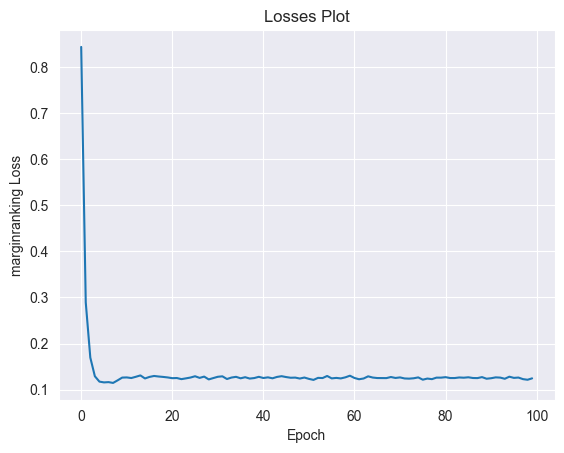

In [5]:
import os
import pickle
from pykeen.pipeline import pipeline

MODEL_DIR = "models/transe_a1"

if os.path.exists(os.path.join(MODEL_DIR, "pipeline_result.pkl")):
    print("Saved model found — loading from disk...")
    with open(os.path.join(MODEL_DIR, "pipeline_result.pkl"), "rb") as f:
        result_transe = pickle.load(f)
    print("Loaded.")
else:
    print("No saved model found — training TransE...")
    result_transe = pipeline(
        training=training,
        testing=testing,
        validation=validation,
        model='TransE',
        model_kwargs=dict(embedding_dim=50),
        optimizer='Adam',
        optimizer_kwargs=dict(lr=0.01),
        training_loop='sLCWA',
        negative_sampler='basic',
        epochs=100,
        random_seed=2026,
        device=device,
    )
    os.makedirs(MODEL_DIR, exist_ok=True)
    result_transe.save_to_directory(MODEL_DIR)
    with open(os.path.join(MODEL_DIR, "pipeline_result.pkl"), "wb") as f:
        pickle.dump(result_transe, f)
    print(f"Model saved to {MODEL_DIR}/")

print(result_transe.metric_results.to_df())
result_transe.plot_losses()

In [6]:
import numpy as np

# Extract entity and relation embeddings from the trained TransE model
entity_embs = result_transe.model.entity_representations[0]().detach().cpu().numpy()
relation_embs = result_transe.model.relation_representations[0]().detach().cpu().numpy()

entity_to_id = result_transe.training.entity_to_id
relation_to_id = result_transe.training.relation_to_id
id_to_entity = {v: k for k, v in entity_to_id.items()}

# Choose a paper
chosen_paper = "paper_6"
paper_id = entity_to_id[chosen_paper]
cites_id = relation_to_id["cites"]

h_emb = entity_embs[paper_id]
r_emb = relation_embs[cites_id]

# Find all papers that chosen_paper actually cites
train_triples = result_transe.training.mapped_triples.numpy()
cited_ids = train_triples[
    (train_triples[:, 0] == paper_id) & (train_triples[:, 1] == cites_id), 2
].tolist()
print(f"Chosen paper : {chosen_paper}")
print(f"Papers it cites (in training set): {len(cited_ids)}")

# Average their embeddings -> centroid of cited works
avg_cited = entity_embs[cited_ids].mean(axis=0)

# TransE: a paper X that cites similar works satisfies X + r ≈ avg_cited
# => X ≈ avg_cited - r
target_emb = avg_cited - r_emb

# Find the paper whose embedding is closest to target_emb
distances = np.linalg.norm(entity_embs - target_emb, axis=1)
distances[paper_id] = np.inf  # exclude chosen paper itself
nearest_id = np.argmin(distances)
nearest_paper = id_to_entity[nearest_id]

print(f"Nearest paper to target: {nearest_paper}  (L2 = {distances[nearest_id]:.4f})")


Chosen paper : paper_6
Papers it cites (in training set): 18
Nearest paper to target: paper_13656  (L2 = 0.6198)


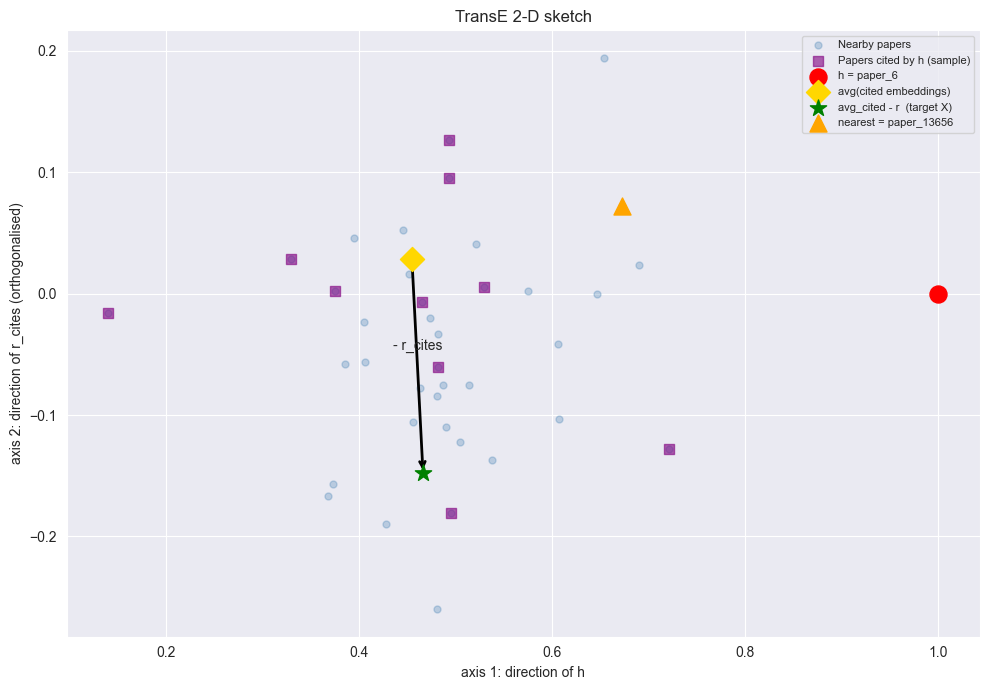

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def project_plane(vecs, u, v):
    e1 = u / (np.linalg.norm(u) + 1e-12)
    v2 = v - np.dot(v, e1) * e1
    e2 = v2 / (np.linalg.norm(v2) + 1e-12)
    return vecs @ np.stack([e1, e2], axis=1)

# Points to plot: neighbours of target + key vectors
k = 30
all_distances = np.linalg.norm(entity_embs - target_emb, axis=1)
top_k_ids = np.argsort(all_distances)[:k].tolist()
plot_ids = list(set(top_k_ids + [paper_id, nearest_id] + cited_ids[:10]))

# Stack all points including avg_cited and target_emb as extra rows
extra = np.vstack([avg_cited.reshape(1, -1), target_emb.reshape(1, -1)])
pts = np.vstack([entity_embs[plot_ids], extra])

pts_2d     = project_plane(pts, h_emb, r_emb)
h_2d       = project_plane(h_emb.reshape(1,      -1), h_emb, r_emb)[0]
avg_2d     = pts_2d[-2]   # avg_cited
target_2d  = pts_2d[-1]   # target = avg_cited - r
nn_2d      = project_plane(entity_embs[nearest_id].reshape(1, -1), h_emb, r_emb)[0]
cited_2d   = project_plane(entity_embs[cited_ids[:10]], h_emb, r_emb)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(pts_2d[:-2, 0], pts_2d[:-2, 1], c="steelblue", alpha=0.3, s=25, label="Nearby papers")
ax.scatter(cited_2d[:, 0], cited_2d[:, 1],  c="purple",   alpha=0.6, s=60, marker="s", label="Papers cited by h (sample)")
ax.scatter(h_2d[0],       h_2d[1],       c="red",    s=150, zorder=5, label=f"h = {chosen_paper}")
ax.scatter(avg_2d[0],     avg_2d[1],     c="gold",   s=150, zorder=5, marker="D", label="avg(cited embeddings)")
ax.scatter(target_2d[0],  target_2d[1],  c="green",  s=150, zorder=5, marker="*", label="avg_cited - r  (target X)")
ax.scatter(nn_2d[0],      nn_2d[1],      c="orange", s=150, zorder=5, marker="^", label=f"nearest = {nearest_paper}")

# Arrow: avg_cited -> target  (subtracting r)
ax.annotate("", xy=target_2d, xytext=avg_2d,
            arrowprops=dict(arrowstyle="->", color="black", lw=2))
span = pts_2d[:, 1].max() - pts_2d[:, 1].min()
mid = (avg_2d + target_2d) / 2
ax.text(mid[0], mid[1] + span * 0.03, "- r_cites", fontsize=10, ha="center")

ax.set_title("TransE 2-D sketch")
ax.set_xlabel("axis 1: direction of h")
ax.set_ylabel("axis 2: direction of r_cites (orthogonalised)")
ax.legend(loc="upper right", fontsize=8, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


## **A.2 Improving TransE**

In the previous task we have used TransE as the base KGE model. This model provides good
interpretability but has some drawbacks. Given the structure and data of our KG, give an
example (i.e., a set of triples) of where the modeling assumptions of TransE fail, and explain
a KGE model which solves this issue.

In [8]:
import os
import numpy as np
from collections import defaultdict
import pandas as pd
import pickle
from pykeen.pipeline import pipeline

# ── 1. Find symmetric citation pairs (TransE failure case) ────────────────────
triple_set = set(zip(heads.tolist(), tails.tolist()))
sym_pairs = [(h, t) for h, t in triple_set if h < t and (t, h) in triple_set]
print(f"Mutual citation pairs in KG: {len(sym_pairs):,}")

h_ex, t_ex = sym_pairs[0]
print(f"Example — paper_{h_ex} <-> paper_{t_ex}:")
print(f"  Triple 1: paper_{h_ex} --cites--> paper_{t_ex}")
print(f"  Triple 2: paper_{t_ex} --cites--> paper_{h_ex}")
print("TransE: h + r = t  AND  t + r = h")
print("  => (h + r) + r = h  =>  r = 0")
print("  Symmetric triples force r toward the zero vector.")

# ── 2. RotatE — handles symmetry with complex-plane rotation ─────────────────
ROTATE_DIR = "models/rotate_a2"

if os.path.exists(os.path.join(ROTATE_DIR, "pipeline_result.pkl")):
    print("Loading RotatE from disk...")
    with open(os.path.join(ROTATE_DIR, "pipeline_result.pkl"), "rb") as f:
        result_rotate = pickle.load(f)
    print("Loaded.")
else:
    print("Training RotatE...")
    result_rotate = pipeline(
        training=training, testing=testing, validation=validation,
        model='RotatE', model_kwargs=dict(embedding_dim=50),
        optimizer='Adam', optimizer_kwargs=dict(lr=0.01),
        training_loop='sLCWA', negative_sampler='basic',
        epochs=100, random_seed=2026, device=device,
    )
    os.makedirs(ROTATE_DIR, exist_ok=True)
    result_rotate.save_to_directory(ROTATE_DIR)
    with open(os.path.join(ROTATE_DIR, "pipeline_result.pkl"), "wb") as f:
        pickle.dump(result_rotate, f)
    print(f"Saved to {ROTATE_DIR}/")

# ── 3. Compare TransE vs RotatE ─────────────────────────────────────────────
def extract_metrics(result, label):
    df = result.metric_results.to_df()
    if 'Side' in df.columns:
        df = df[df['Side'] == 'both']
    if 'Rank_type' in df.columns:
        df = df[df['Rank_type'] == 'realistic']
    row = df[df['Metric'].isin(['hits_at_1', 'hits_at_3', 'inverse_harmonic_mean_rank'])]
    return {'Model': label, **dict(zip(row['Metric'], row['Value']))}

cmp = pd.DataFrame([
    extract_metrics(result_transe, 'TransE'),
    extract_metrics(result_rotate, 'RotatE'),
]).set_index('Model').round(4)
print("", cmp)


Mutual citation pairs in KG: 44,324
Example — paper_6690 <-> paper_11450:
  Triple 1: paper_6690 --cites--> paper_11450
  Triple 2: paper_11450 --cites--> paper_6690
TransE: h + r = t  AND  t + r = h
  => (h + r) + r = h  =>  r = 0
  Symmetric triples force r toward the zero vector.
Loading RotatE from disk...
Loaded.
         inverse_harmonic_mean_rank  hits_at_1  hits_at_3
Model                                                   
TransE                      0.0424     0.0000     0.0503
RotatE                      0.5061     0.4297     0.5363


Ejemplo de tripletas donde falla TransE

  En el grafo PubMed hay citas mutuas, por ejemplo:

  paper_3 --cites--> paper_7
  paper_7 --cites--> paper_3

  Estas dos tripletas forman una relación simétrica: si A cita a B, entonces B cita a A.

  ---
  Por qué falla TransE

  TransE modela cada triple como h + r ≈ t. Aplicado a las dos tripletas anteriores:

  paper_3 + r_cites ≈ paper_7   (triple 1)
  paper_7 + r_cites ≈ paper_3   (triple 2)

  Sumando ambas ecuaciones:

  (paper_3 + r) + r ≈ paper_3
  => 2·r ≈ 0
  => r ≈ 0

  Para satisfacer ambas tripletas a la vez, TransE se ve forzado a empujar el vector de relación r_cites hacia el vector
   cero. Esto destruye la capacidad expresiva de la relación: un vector nulo no puede distinguir qué papers están
  relacionados entre sí.

  ---
  Por qué RotatE lo resuelve

  RotatE trabaja en el espacio complejo y modela la relación como una rotación: t = h ⊙ r, donde ⊙ es el producto
  elemento a elemento en ℂ y cada componente de r tiene módulo 1 (es decir, r es un vector de fases).

  Para una relación simétrica, basta con que la fase de r sea exactamente π (180°):

  t = h ⊙ r      (rotar h en π  =>  t)
  h = t ⊙ r      (rotar t en π  =>  h, porque rotar dos veces en π vuelve al origen)

  Rotar 180° es su propia inversa, así que RotatE puede representar simetría sin colapsar r a cero. La relación sigue
  siendo un vector no trivial (fase π ≠ 0) y mantiene toda su capacidad de discriminar entidades.

## **A.3 Training KGEs**

Now, train different translational and semantic KGE models on the KG (we recommend at
least 4 models) and report and comment the Hits@1, Hits@3 and MRR results
based on your interpretation of the models. Keep your best performing embeddings,
as we will need them later. Also, explore and comment on the effects of the training
parameters, both the expected and the observed, for embedding dimension, number
of negative samples per positive sample and the loss margin.


Training / loading main models...
  Loading models/distmult_a3...
  Loading models/complex_a3...

── Model comparison ──
          inverse_harmonic_mean_rank  hits_at_1  hits_at_3
Model                                                     
TransE                        0.0424     0.0000     0.0503
RotatE                        0.5061     0.4297     0.5363
DistMult                      0.2077     0.1409     0.2186
ComplEx                       0.2981     0.2292     0.3172


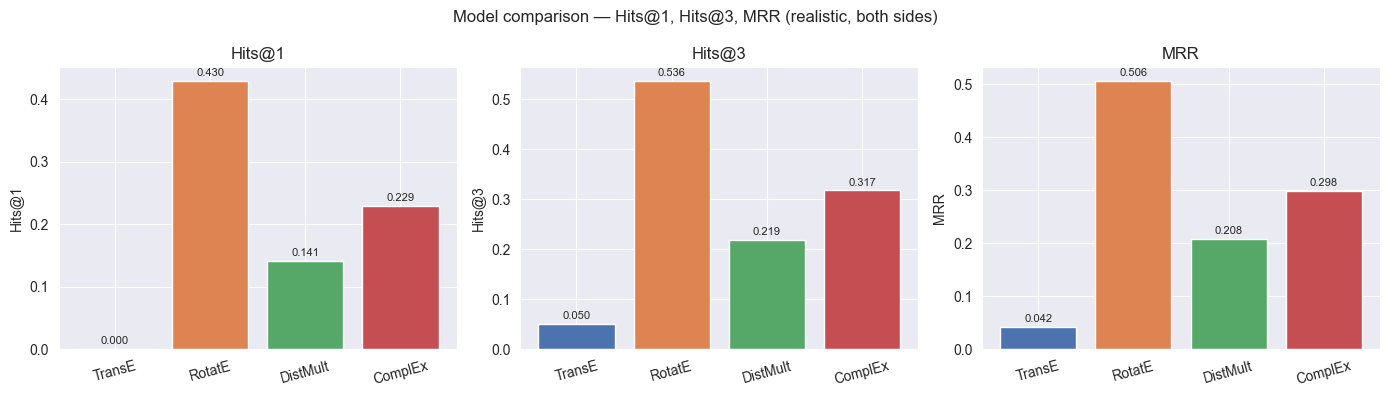


Hyperparameter exploration...
  Training RotatE...


Training epochs on cpu:   0%|          | 0/30 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/278 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/278 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/8.87k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 24.44s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=19717, num_relations=1, create_inverse_triples=False, num_triples=70918) to file:///D:/cosas_uni/master/Q2_25-26/SDM/SDM_Lab3/models/hp_rotate_margin5_0/training_triples
INFO:pykeen.pipeline.api:Saved to directory: D:\cosas_uni\master\Q2_25-26\SDM\SDM_Lab3\models\hp_rotate_margin5_0


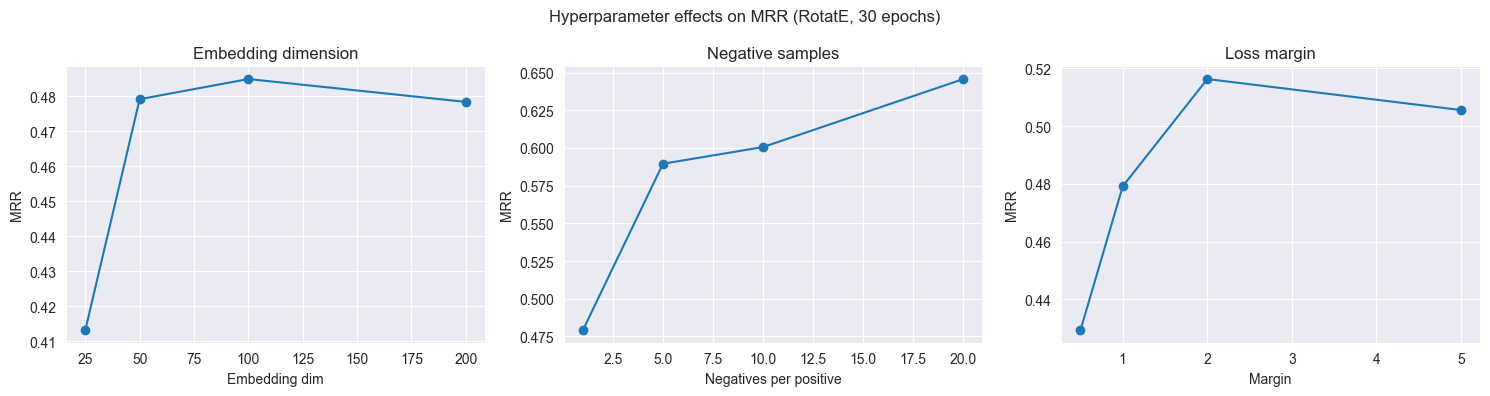


Best model: RotatE
KGE embedding matrix for B.5: (19717, 100)


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pickle
from pykeen.pipeline import pipeline

def train_or_load(model_name, model_kwargs, save_dir, epochs=100,
                  loss=None, loss_kwargs=None, neg_sampler_kwargs=None):
    if os.path.exists(os.path.join(save_dir, "pipeline_result.pkl")):
        print(f"  Loading {save_dir}...")
        with open(os.path.join(save_dir, "pipeline_result.pkl"), "rb") as f:
            return pickle.load(f)
    print(f"  Training {model_name}...")
    kw = dict(
        training=training, testing=testing, validation=validation,
        model=model_name, model_kwargs=model_kwargs,
        optimizer='Adam', optimizer_kwargs=dict(lr=0.01),
        training_loop='sLCWA', negative_sampler='basic',
        epochs=epochs, random_seed=2026, device=device,
    )
    if loss:
        kw['loss'] = loss
        if loss_kwargs:
            kw['loss_kwargs'] = loss_kwargs
    if neg_sampler_kwargs:
        kw['negative_sampler_kwargs'] = neg_sampler_kwargs
    r = pipeline(**kw)
    os.makedirs(save_dir, exist_ok=True)
    r.save_to_directory(save_dir)
    with open(os.path.join(save_dir, "pipeline_result.pkl"), "wb") as f:
        pickle.dump(r, f)
    return r

def get_metrics(result, label):
    df = result.metric_results.to_df()
    if 'Side' in df.columns:
        df = df[df['Side'] == 'both']
    if 'Rank_type' in df.columns:
        df = df[df['Rank_type'] == 'realistic']
    row = df[df['Metric'].isin(['hits_at_1', 'hits_at_3', 'inverse_harmonic_mean_rank'])]
    return {'Model': label, **dict(zip(row['Metric'], row['Value']))}

# ── Main models ───────────────────────────────────────────────────────────────
print("Training / loading main models...")
result_distmult = train_or_load('DistMult', dict(embedding_dim=50), 'models/distmult_a3')
result_complex  = train_or_load('ComplEx',  dict(embedding_dim=50), 'models/complex_a3')

df_main = pd.DataFrame([
    get_metrics(result_transe,   'TransE'),
    get_metrics(result_rotate,   'RotatE'),
    get_metrics(result_distmult, 'DistMult'),
    get_metrics(result_complex,  'ComplEx'),
]).set_index('Model').round(4)
print("\n── Model comparison ──")
print(df_main)

# ── Bar chart: model comparison ───────────────────────────────────────────────
metrics_plot = ['hits_at_1', 'hits_at_3', 'inverse_harmonic_mean_rank']
labels_plot  = ['Hits@1',    'Hits@3',    'MRR']
x = np.arange(len(df_main))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']
for ax, metric, lbl in zip(axes, metrics_plot, labels_plot):
    vals = df_main[metric].values
    bars = ax.bar(x, vals, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(df_main.index, rotation=15)
    ax.set_ylabel(lbl)
    ax.set_title(lbl)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)
plt.suptitle('Model comparison — Hits@1, Hits@3, MRR (realistic, both sides)')
plt.tight_layout()
plt.show()

# ── Hyperparameter exploration (RotatE, 30 epochs each) ───────────────────────
print("\nHyperparameter exploration...")

dim_mrr, neg_mrr, margin_mrr = {}, {}, {}

for dim in [25, 50, 100, 200]:
    r = train_or_load('RotatE', dict(embedding_dim=dim), f'models/hp_rotate_dim{dim}', epochs=30)
    dim_mrr[dim] = get_metrics(r, str(dim))['inverse_harmonic_mean_rank']

for n in [1, 5, 10, 20]:
    r = train_or_load('RotatE', dict(embedding_dim=50), f'models/hp_rotate_negs{n}', epochs=30,
                      neg_sampler_kwargs=dict(num_negs_per_pos=n))
    neg_mrr[n] = get_metrics(r, str(n))['inverse_harmonic_mean_rank']

for m in [0.5, 1.0, 2.0, 5.0]:
    key = str(m).replace('.', '_')
    r = train_or_load('RotatE', dict(embedding_dim=50), f'models/hp_rotate_margin{key}', epochs=30,
                      loss='MarginRankingLoss', loss_kwargs=dict(margin=m))
    margin_mrr[m] = get_metrics(r, str(m))['inverse_harmonic_mean_rank']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, d, xlabel, title in [
    (axes[0], dim_mrr,    'Embedding dim',          'Embedding dimension'),
    (axes[1], neg_mrr,    'Negatives per positive', 'Negative samples'),
    (axes[2], margin_mrr, 'Margin',                 'Loss margin'),
]:
    ax.plot(list(d.keys()), list(d.values()), 'o-')
    ax.set_xlabel(xlabel); ax.set_ylabel('MRR'); ax.set_title(title)
plt.suptitle('Hyperparameter effects on MRR (RotatE, 30 epochs)')
plt.tight_layout(); plt.show()

# ── Save best KGE embeddings aligned to PyG node order (for B.5) ─────────────
results_map = {'TransE': result_transe, 'RotatE': result_rotate,
               'DistMult': result_distmult, 'ComplEx': result_complex}
best_model_name = df_main['inverse_harmonic_mean_rank'].idxmax()
best_result_kge = results_map[best_model_name]

raw_embs = best_result_kge.model.entity_representations[0]().detach()
if raw_embs.is_complex():
    raw_embs = torch.view_as_real(raw_embs).reshape(raw_embs.shape[0], -1)
raw_embs = raw_embs.cpu().numpy()

best_entity_to_id = best_result_kge.training.entity_to_id
n_nodes = data.num_nodes
kge_node_embs = np.zeros((n_nodes, raw_embs.shape[1]), dtype=np.float32)
for i in range(n_nodes):
    key = f"paper_{i}"
    if key in best_entity_to_id:
        kge_node_embs[i] = raw_embs[best_entity_to_id[key]]

print(f"\nBest model: {best_model_name}")
print(f"KGE embedding matrix for B.5: {kge_node_embs.shape}")

## **A.4 Negative Sampling**

In PyKEEN, there exist two different strategies to generate negative samples (Uniform
Sampling and Bernoulli Sampling), which change the probability that they give to corrupt
either the tail entity or the head entity in the triple. Given our KG, compute the corruption
probabilities that they assign. Why do we obtain these results? Are we benefiting from the
Bernoulli Sampling strategy?

In [19]:
import numpy as np
from collections import defaultdict

# ── Compute tph and hpt from training triples ─────────────────────────────────
train_triples = training.mapped_triples.numpy()  # (N, 3): [head_id, rel_id, tail_id]

head_to_tails = defaultdict(set)
tail_to_heads = defaultdict(set)
for h, r, t in train_triples:
    head_to_tails[int(h)].add(int(t))
    tail_to_heads[int(t)].add(int(h))

tph = np.mean([len(v) for v in head_to_tails.values()])
hpt = np.mean([len(v) for v in tail_to_heads.values()])

p_head_bern = tph / (tph + hpt)
p_tail_bern = hpt / (tph + hpt)

print(f"Training triples      : {len(train_triples):,}")
print(f"Unique heads          : {len(head_to_tails):,}")
print(f"Unique tails          : {len(tail_to_heads):,}")
print(f"\nAvg tails per head (tph) : {tph:.3f}")
print(f"Avg heads per tail (hpt) : {hpt:.3f}")
print(f"\n{'Strategy':<12} {'P(corrupt head)':<20} {'P(corrupt tail)'}")
print('-' * 52)
print(f"{'Uniform':<12} {0.5:<20.4f} {0.5:.4f}")
print(f"{'Bernoulli':<12} {p_head_bern:<20.4f} {p_tail_bern:.4f}")
print(f"\ntph ≈ hpt because the PubMed graph is undirected: every edge (A,B)")
print(f"appears as both (A cites B) and (B cites A), making out-degree ≈ in-degree.")
print(f"=> Bernoulli collapses to Uniform (50/50) and provides no benefit here.")


Training triples      : 70,918
Unique heads          : 19,717
Unique tails          : 17,353

Avg tails per head (tph) : 3.597
Avg heads per tail (hpt) : 4.087

Strategy     P(corrupt head)      P(corrupt tail)
----------------------------------------------------
Uniform      0.5000               0.5000
Bernoulli    0.4681               0.5319

tph ≈ hpt because the PubMed graph is undirected: every edge (A,B)
appears as both (A cites B) and (B cites A), making out-degree ≈ in-degree.
=> Bernoulli collapses to Uniform (50/50) and provides no benefit here.


## **A.5 Disconnected paper** 
Imagine we accidentally leave a paper in our dataset that neither cites any paper nor has any
citations. After training the KGEs, what will have happened to the embedding vector of this
isolated paper? If we visualized this vector in 2D using PCA or any other dimensionality
reduction technique, where do you expect it to be located?

**Answer:**

Since the isolated paper appears in no triple (neither as head nor as tail), **its embedding is never reached by any gradient** during training. It retains its random initialisation throughout the training process.

**Effect on the embedding vector:**  
The parameters stay at their initial random values, drawn from the model's initialisation distribution (typically a small Gaussian or uniform). The vector has no meaningful position in the learned relational geometry.

**Where it appears in a 2-D PCA (or similar) plot:**  
PCA finds the directions of maximum variance across *trained* embeddings, which cluster in regions reflecting citation structure. The isolated paper's random embedding is uncorrelated with that structure, so it appears **as an outlier** — displaced from all semantic clusters, likely near the origin (if initialised with small values) or at the periphery of the plot.


## **Loading the full PubMed Dataset**

In [ ]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]

print(data)
print("Number of node features:", dataset.num_node_features)
print("Number of classes:", dataset.num_classes)

data = data.to('cuda' if torch.cuda.is_available() else 'cpu')

## **B.1: Let's Forget About the Graph**

In [ ]:
import numpy as np

X = data.x.cpu().numpy()
y = data.y.cpu().numpy()

train_mask = data.train_mask.cpu().numpy()
test_mask = data.test_mask.cpu().numpy()

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

With the dataset above, train three or four simple classifiers (e.g., SVM, LR, RF, KNN...) and report the accuracy score over the test set for them.

*Note: use **sklearn** for simplicity.*

## **B.2: Exploiting the Graph Structure**

Now, we are going to create a GNN with graph layers and a final linear layer. Refer to the Lab Statement for more details of how to implement the architecture. You should report your designed architecutre(s) and the accuracy results.

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn
# Remember to import the GNN modules you want to use


class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels): #You can change it at will (e.g., two different hidden channel sizes)
        super().__init__()

        # Your code here

    def forward(self, x, edge_index, return_embeddings=False):
        # Your code here

        return x


In [ ]:
# You are provided with a simple training and testing loop. Feel free to create your own improved versions.

gnn_model = GNN(dataset.num_node_features, 256, dataset.num_classes).to(device) #Remember to change it if you change the input parameters in the GNN class
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01, weight_decay=5e-4)


def train_gnn(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test_gnn(model):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    correct = pred[data.test_mask] == data.y[data.test_mask]
    acc = int(correct.sum()) / int(data.test_mask.sum())
    return acc

for epoch in range(500):
    loss = train_gnn(gnn_model)

gnn_acc = test_gnn(gnn_model)
print("Test Accuracy:", gnn_acc)

## **B.4: The More the Merrier?**

Create new GNN models with 2, 4, 8 and 16 GNN layers and report the accuracy results. What do you observe? Why do you think it is happening?

## **B.5: What if we do  not have Initial Information?**

Train your previosuly best performing model with randomly initialized features and report the results:

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]
data.x = #Replace the features for a 256 dimension random vector
data = data.to(device)

Now, we will see how to initialize the GNN with the embeddings resulting from a Knowledge Graph Embedding Model.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = Planetoid(root='data/PubMed', name='PubMed')
data = dataset[0]
data.x = #your_kge_embeddings (ensure they follow the same order!)
data = data.to(device)

Now, train again a GNN with the TransE embeddings as initialization:

In [ ]:
# Train

## **B.7: Where are the Embeddings?**

In this task we will obtaint the embeddings generated by our GNN architecture. First, update and retrain you best performing GNN model so that it returns the embeddings (see the lab statement for details).

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn
# Remember to import the GNN/DL modules you want to use


class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels): #You can change it at will (e.g., two different hidden channel sizes)
        super().__init__()

        # Your code here

    def forward(self, x, edge_index, return_embeddings=False):
        # Your code here

        return x

gnn_model = GNN(dataset.num_node_features, 256, dataset.num_classes).to(device) #Remember to change it if you change the input parameters in the GNN class
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.01, weight_decay=5e-4)


def train_gnn(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

for epoch in range(500):
    loss = train_gnn(gnn_model)

Obtain the embeddings:

In [ ]:
gnn_model.eval()
embs = gnn_model(data.x, data.edge_index, return_embs=True)
embs = embs.detach().cpu().numpy()

Once you have obtained the embeddings, apply dimensionality reduction (e.g., PCA) and visualize the result by coloring each embedding with its corresponding class.

## **B.8 Embedding spaces**